In [47]:
## 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
## 2. Load Dataset
df = pd.read_csv("SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [49]:
## 3. Data Exploration
df.info()
df.describe()
print(df.columns)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [50]:
## 4. Data Cleaning
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [51]:
# Handle missing values after conversion
df = df.dropna()

In [52]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')

In [53]:
df['ship_date'] = pd.to_datetime(df['ship_date'],format='mixed',dayfirst=True)

In [54]:
df['month'] = df['order_date'].dt.month

In [55]:
## 5. Exploratory Data Analysis
### Analyzing sales performance across different dimensions
region_sales = df.groupby('region')['sales'].sum()
print('Region_Sales:\n',region_sales)

Region_Sales:
 region
Africa             538115.0
Canada              50314.0
Caribbean          251441.0
Central           1806638.0
Central Asia       389506.0
EMEA               575562.0
East               366492.0
North              790546.0
North Asia         453686.0
Oceania            625382.0
South             1031101.0
Southeast Asia     532172.0
West               424173.0
Name: sales, dtype: float64


In [56]:
category_sales = df.groupby('category')['sales'].sum()
print('Category_sales: \n',category_sales)

Category_sales: 
 category
Furniture          2406605.0
Office Supplies    2790258.0
Technology         2638265.0
Name: sales, dtype: float64


In [57]:
total_sales = df['sales'].sum()
print("Total Sales: \n", total_sales)

Total Sales: 
 7835128.0


In [58]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
print('Top_Products: \n',top_products)

Top_Products: 
 product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64


In [59]:
df.groupby('category')['profit'].sum()

,profit
category,
Furniture,97049.37790
Office Supplies,350107.32450
Technology,267573.47238


In [60]:
monthly_sales = df.groupby('month')['sales'].sum()
print('Monthly_Sales: \n',monthly_sales)

Monthly_Sales: 
 month
1     475695.0
2     455796.0
3     557679.0
4     531722.0
5     592614.0
6     745063.0
7     554111.0
8     736964.0
9     783356.0
10    697796.0
11    877597.0
12    826735.0
Name: sales, dtype: float64


In [61]:
market_sales = df.groupby('market')['sales'].sum()
print(market_sales)

market
APAC      2000746.0
Africa     538115.0
Canada      50314.0
EMEA       575562.0
EU        1803099.0
LATAM     1563126.0
US        1304166.0
Name: sales, dtype: float64


In [62]:
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customer_name
Eric Murdock        19489.0
John Grady          19483.0
Maria Etezadi       18237.0
Theone Pippenger    17416.0
Dan Reichenbach     16705.0
Ben Ferrer          16661.0
Randy Bradley       16399.0
Mathew Reese        16125.0
Muhammed Yedwab     16091.0
Steven Ward         15984.0
Name: sales, dtype: float64


In [75]:
# Calculate average shipping time
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days
print("Average Shipping Time:", df['shipping_time'].mean())

Average Shipping Time: 15.129449239621866


In [64]:
df.groupby('discount')['profit'].mean()

,profit
discount,
0.000,38.923680
0.002,99.322408
0.070,88.224127
0.100,38.130905
0.150,28.099266
0.170,20.575855
0.200,14.342183
0.202,-9.480768
0.250,-0.783920


In [65]:
df.groupby('ship_mode')['shipping_cost'].mean()

,shipping_cost
ship_mode,
First Class,28.200886
Same Day,28.427453
Second Class,20.095148
Standard Class,13.223419


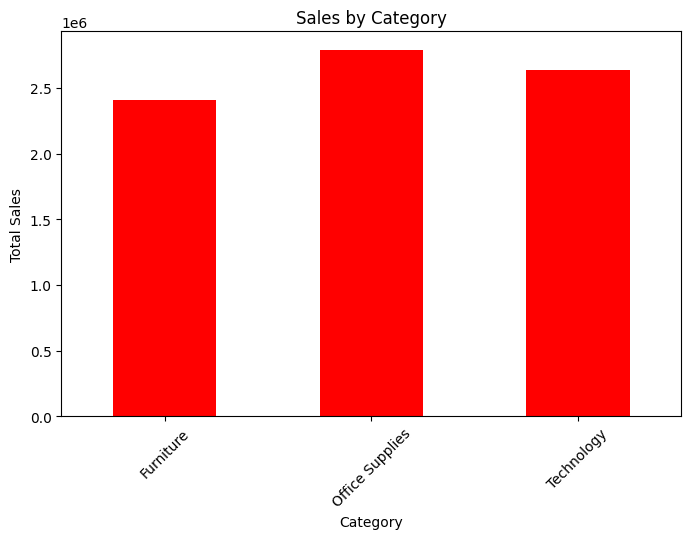

In [76]:
## 6. Data Visualization
category_sales.plot(kind='bar', figsize=(8,5),color='red')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

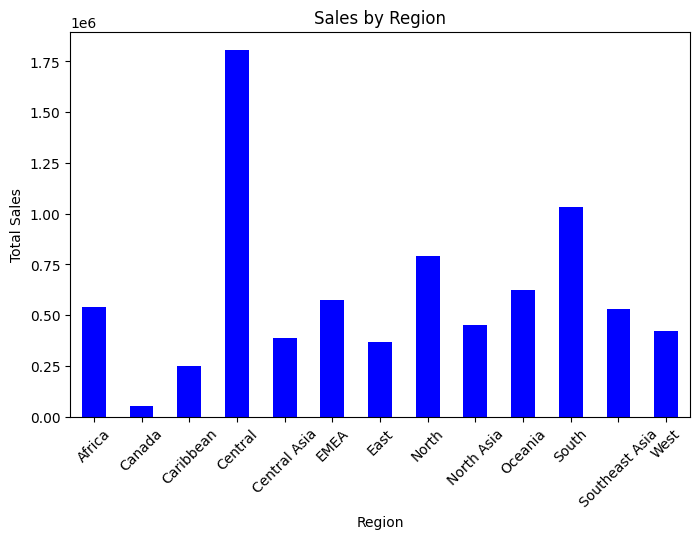

In [77]:
region_sales.plot(kind='bar',figsize=(8,5),color='blue')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

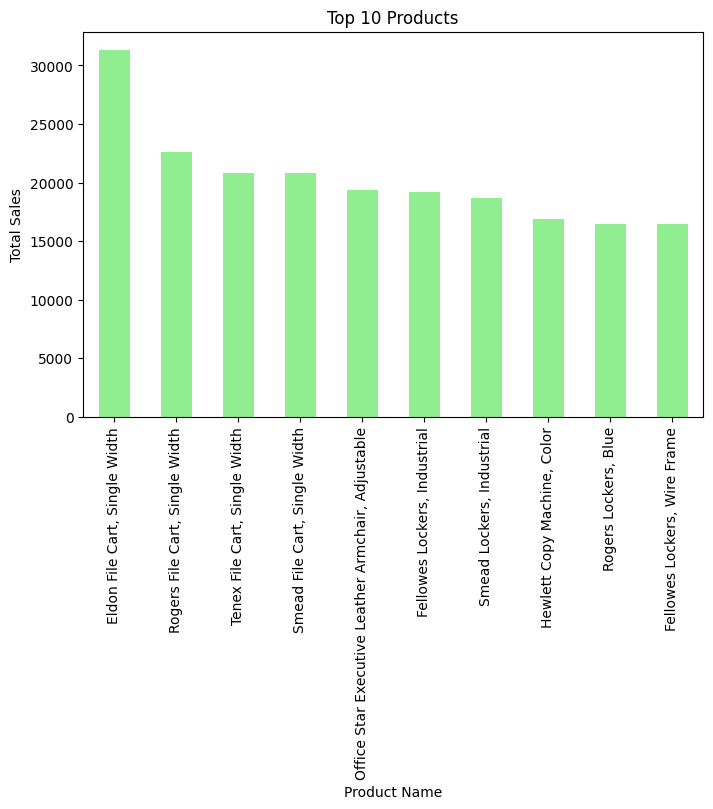

In [96]:
top_products.plot(kind='bar',color='lightgreen',figsize=(8,5))
plt.title("Top 10 Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.show()

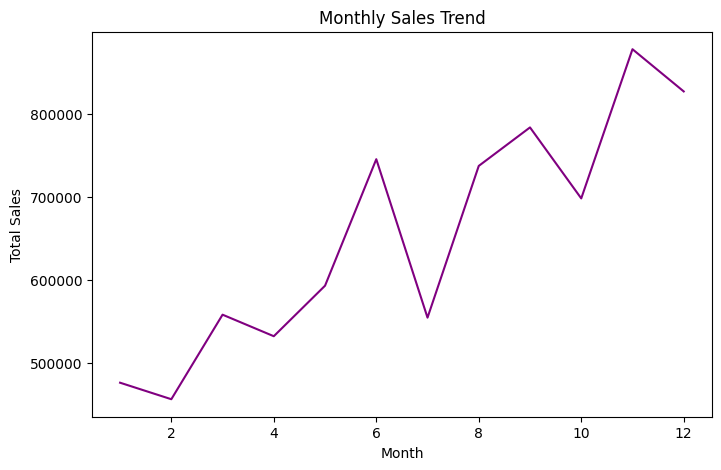

In [83]:
monthly_sales.plot(color='purple',figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

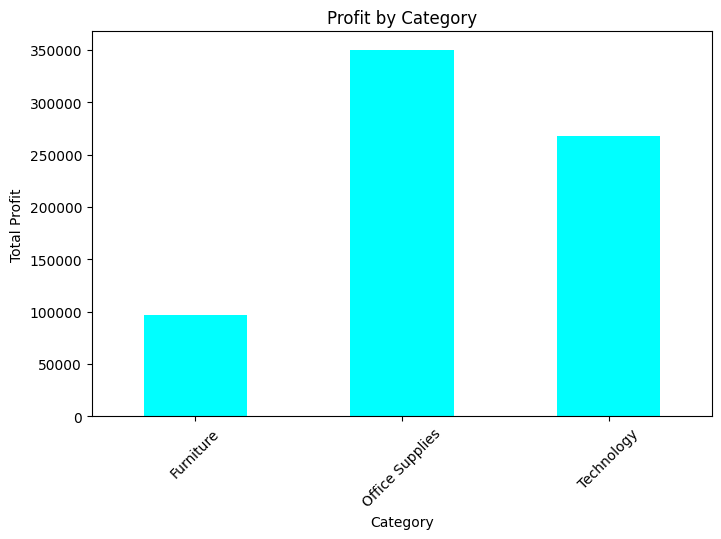

In [84]:
profit_by_category.plot(kind='bar',color='cyan',figsize=(8,5))
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

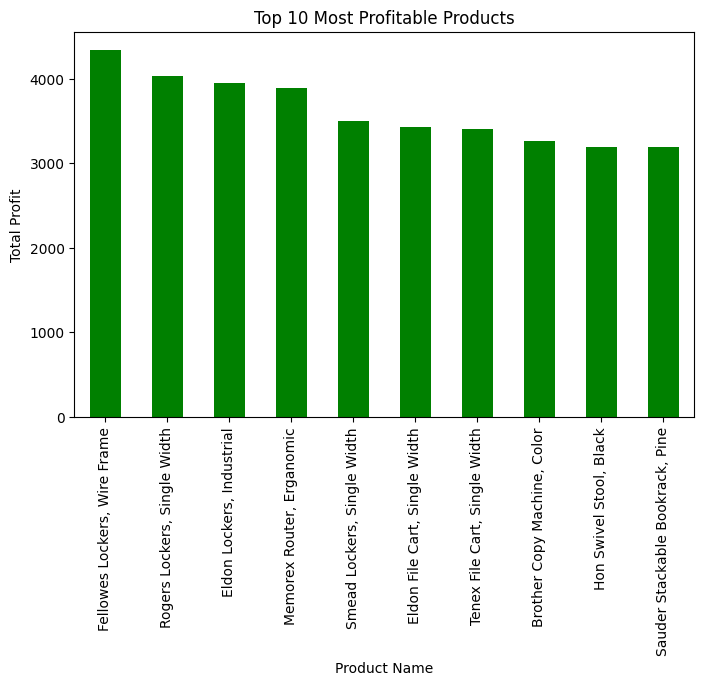

In [95]:
top_profit_products.plot(kind='bar',color='green',figsize=(8,5))
plt.title("Top 10 Most Profitable Products")
plt.xlabel("Product Name")
plt.ylabel("Total Profit")
plt.xticks(rotation=90)
plt.show()

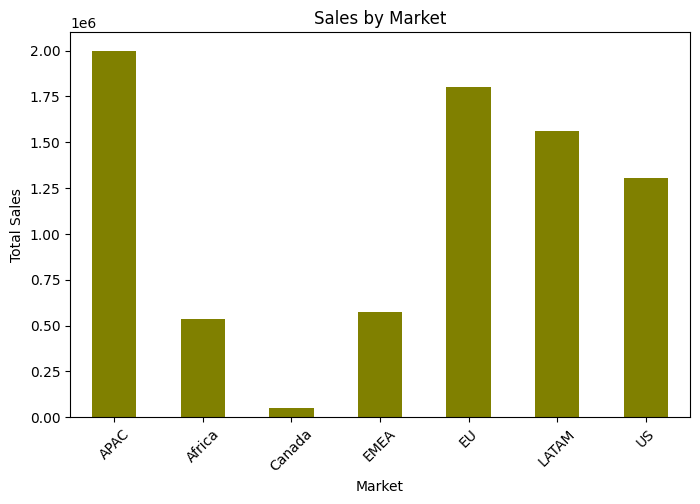

In [97]:
market_sales.plot(kind='bar',color='olive',figsize=(8,5))
plt.title("Sales by Market")
plt.xlabel("Market")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [66]:
## 7. Profit Analysis
profit_by_category = df.groupby('category')['profit'].sum()
print(profit_by_category)

category
Furniture           97049.37790
Office Supplies    350107.32450
Technology         267573.47238
Name: profit, dtype: float64


In [67]:
top_profit_products = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)
print(top_profit_products)

product_name
Fellowes Lockers, Wire Frame       4342.0220
Rogers Lockers, Single Width       4031.4525
Eldon Lockers, Industrial          3950.5290
Memorex Router, Erganomic          3885.7520
Smead Lockers, Single Width        3499.1055
Eldon File Cart, Single Width      3429.3687
Tenex File Cart, Single Width      3405.0432
Brother Copy Machine, Color        3267.6908
Hon Swivel Stool, Black            3192.6586
Sauder Stackable Bookrack, Pine    3188.5183
Name: profit, dtype: float64


In [99]:
## 7. Business Insights
- Technology category generates high profit.
- Some products have high sales but low profit due to discounts.
- Certain regions contribute more to total revenue.
- Monthly sales show variation indicating demand patterns.
- Shipping time impacts customer experience.